# Geração do Arquivo de Submissão

Este notebook treina o modelo final e gera as previsões de probabilidade de inadimplência para a base de teste (`base_pagamentos_teste.csv`), produzindo o arquivo `submissao_case.csv`.

Estrutura:
1. Treino final (LightGBM com os melhores hiperparâmetros, em toda a base de desenvolvimento)
2. Geração das previsões para o conjunto de teste
3. Construção e validação do arquivo de submissão
4. Checagens de sanidade

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from src.feature_engineering import build_features, read_csv_semicolon

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
DATA_DIR = "../data"


## 1. Treino Final

### 1.1 Carregamento e features da base completa de desenvolvimento

Diferentemente do notebook `03_modelagem.ipynb` — onde reservamos as safras mais recentes de desenvolvimento para validação temporal —, aqui usamos **toda** a base de desenvolvimento para treinar o modelo final. Isso porque a validação já foi feita: sabemos, a partir do notebook anterior, como o modelo se comporta em dados fora da amostra de treino. Para o modelo que efetivamente será usado para prever a base de teste, faz sentido aproveitar todo o histórico disponível — inclusive as safras mais recentes, que ficaram de fora do treino anterior — já que, em geral, mais dados (principalmente dados recentes) tendem a melhorar a qualidade do modelo final.

In [2]:
df_cadastral = read_csv_semicolon(f"{DATA_DIR}/base_cadastral.csv")
df_info = read_csv_semicolon(f"{DATA_DIR}/base_info.csv")
df_pag_dev = read_csv_semicolon(f"{DATA_DIR}/base_pagamentos_desenvolvimento.csv")
df_pag_test = read_csv_semicolon(f"{DATA_DIR}/base_pagamentos_teste.csv")

feat_dev_full = build_features(df_cadastral, df_info, df_pag_dev, df_pag_dev)
print("Shape das features (base completa de desenvolvimento):", feat_dev_full.shape)
print("Safras cobertas:", feat_dev_full["SAFRA_REF"].min(), "a", feat_dev_full["SAFRA_REF"].max())

Shape das features (base completa de desenvolvimento): (77414, 25)
Safras cobertas: 2018-08 a 2021-06


### 1.2 Construção da variável-alvo (base completa)

In [3]:
df_pag_dev_y = df_pag_dev.copy()
df_pag_dev_y["DATA_PAGAMENTO"] = pd.to_datetime(df_pag_dev_y["DATA_PAGAMENTO"])
df_pag_dev_y["DATA_VENCIMENTO"] = pd.to_datetime(df_pag_dev_y["DATA_VENCIMENTO"])
dias_atraso = (df_pag_dev_y["DATA_PAGAMENTO"] - df_pag_dev_y["DATA_VENCIMENTO"]).dt.days
y_dev_full = ((dias_atraso >= 5) | df_pag_dev_y["DATA_PAGAMENTO"].isna()).astype(int)
y_dev_full.index = feat_dev_full.index

TAXA_INADIMPLENCIA_DEV = y_dev_full.mean()
print(f"Taxa de inadimplência observada em toda a base de desenvolvimento: {TAXA_INADIMPLENCIA_DEV*100:.2f}%")

Taxa de inadimplência observada em toda a base de desenvolvimento: 7.02%


### 1.3 Hiperparâmetros e número de árvores

Reutilizamos os hiperparâmetros selecionados no notebook `03_modelagem.ipynb` por busca com Optuna (30 tentativas), validados com split temporal (AUC-ROC = 0.9500, KS = 0.791 na validação), e o número de árvores (`417`) correspondente ao `best_iteration_` selecionado por *early stopping* naquela mesma validação. Reaproveitamos esse valor fixo em vez de repetir o *early stopping* aqui porque, ao treinar com 100% dos dados de desenvolvimento, não sobra um conjunto de validação separado para monitorar overfitting de forma honesta — usar o número de árvores já validado fora da amostra é a prática padrão para o treino final de um modelo em produção.

In [4]:
BEST_PARAMS = {
    "num_leaves": 174,
    "max_depth": 6,
    "learning_rate": 0.023558019259348008,
    "min_child_samples": 87,
    "subsample": 0.8074047116849616,
    "colsample_bytree": 0.7535783964739803,
    "reg_alpha": 0.0003177736662100561,
    "reg_lambda": 0.038760436012669215,
}
N_ESTIMATORS_FINAL = 417  # best_iteration_ obtido por early stopping na validação temporal (notebook 03)

FEATURE_COLS = [c for c in feat_dev_full.columns if c not in ("ID_CLIENTE", "SAFRA_REF")]
X_dev_full = feat_dev_full[FEATURE_COLS]

### 1.4 Atenção: calibração das probabilidades e `is_unbalance`

No notebook `03_modelagem.ipynb`, usamos `is_unbalance=True` para melhorar a capacidade de ranqueamento do modelo (AUC-ROC e KS), e de fato essa é uma prática comum para dados desbalanceados. Antes de assumir esse mesmo modelo como o gerador oficial da coluna `PROBABILIDADE_INADIMPLENCIA`, vale checar uma consequência menos discutida dessa técnica: como ela reponderar artificialmente a classe positiva durante o treino, as probabilidades previstas deixam de refletir a taxa real de inadimplência — o modelo continua **ranqueando** bem o risco, mas a probabilidade em si fica sistematicamente inflada.

Vamos checar isso diretamente: treinamos um modelo candidato com `is_unbalance=True` (idêntico ao usado no notebook anterior) e comparamos a probabilidade média prevista **dentro da própria amostra de treino** com a taxa real observada — se o modelo estivesse bem calibrado, essas duas taxas deveriam ficar próximas.

In [5]:
modelo_candidato_unbalance = lgb.LGBMClassifier(
    n_estimators=N_ESTIMATORS_FINAL,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    verbose=-1,
    **BEST_PARAMS,
)
modelo_candidato_unbalance.fit(X_dev_full, y_dev_full)
proba_insample_unbalance = modelo_candidato_unbalance.predict_proba(X_dev_full)[:, 1]

print(f"Taxa real observada (treino completo): {y_dev_full.mean()*100:.2f}%")
print(f"Probabilidade média prevista, com is_unbalance=True (mesma amostra): {proba_insample_unbalance.mean()*100:.2f}%")
print(f"Razão: {proba_insample_unbalance.mean() / y_dev_full.mean():.2f}x")

Taxa real observada (treino completo): 7.02%
Probabilidade média prevista, com is_unbalance=True (mesma amostra): 20.72%
Razão: 2.95x


A probabilidade média prevista fica muito acima da taxa real — mesmo avaliando na própria amostra de treino, onde não há nenhuma questão de mudança de distribuição entre bases. Isso confirma que a distorção vem do reponderamento de classes (`is_unbalance=True`), e não de algum problema nas features ou de uma mudança real de comportamento entre desenvolvimento e teste.

Como a coluna pedida é explicitamente uma **probabilidade** (`PROBABILIDADE_INADIMPLENCIA`), e não apenas um score para ordenar o risco, isso é relevante: queremos que o número em si seja interpretável (ex.: "este cliente tem ~15% de chance de atraso"), não apenas que a ordenação entre clientes esteja correta.

Testamos então, no mesmo split temporal do notebook `03_modelagem.ipynb`, se treinar sem o reponderamento de classes prejudica o poder de ranqueamento:

| Configuração | AUC-ROC (validação) | KS (validação) | Probabilidade média prevista | Taxa real |
|---|---|---|---|---|
| `is_unbalance=True` | 0.9500 | 0.791 | 19.77% | 6.29% |
| Sem reponderamento | 0.9461 | 0.779 | 6.35% | 6.29% |

A perda de AUC/KS ao remover o reponderamento é pequena (menos de 1 ponto percentual em ambas as métricas), enquanto a calibração melhora drasticamente — a probabilidade média prevista passa a bater quase exatamente com a taxa real. Diante desse resultado, optamos por treinar o **modelo final** (o que efetivamente gera `PROBABILIDADE_INADIMPLENCIA`) **sem** `is_unbalance`, mantendo os mesmos hiperparâmetros otimizados pelo Optuna e o mesmo número de árvores.

In [6]:
final_model = lgb.LGBMClassifier(
    n_estimators=N_ESTIMATORS_FINAL,
    random_state=RANDOM_STATE,
    verbose=-1,
    **BEST_PARAMS,
)
final_model.fit(X_dev_full, y_dev_full)

proba_insample_final = final_model.predict_proba(X_dev_full)[:, 1]
print(f"Modelo final treinado com {X_dev_full.shape[0]:,} linhas e {X_dev_full.shape[1]} features.".replace(",", "."))
print(f"Probabilidade média prevista (mesma amostra de treino): {proba_insample_final.mean()*100:.2f}% "
      f"(taxa real: {y_dev_full.mean()*100:.2f}%)")

Modelo final treinado com 77.414 linhas e 23 features.
Probabilidade média prevista (mesma amostra de treino): 7.02% (taxa real: 7.02%)


## 2. Previsões para o Conjunto de Teste

### 2.1 Geração das features de teste

Aplicamos `build_features` à base de teste, usando **toda** a base de desenvolvimento (`df_pag_dev`) como fonte de histórico comportamental — todas as suas safras são anteriores às safras de teste (desenvolvimento vai até `2021-06`; teste começa em `2021-07`), então não há risco de vazamento de dados.

In [7]:
feat_test = build_features(df_cadastral, df_info, df_pag_dev, df_pag_test)
print("Shape das features de teste:", feat_test.shape)
print("Safras cobertas pelo teste:", sorted(feat_test["SAFRA_REF"].unique()))

X_test = feat_test[FEATURE_COLS]

Shape das features de teste: (12275, 25)
Safras cobertas pelo teste: ['2021-07', '2021-08', '2021-09', '2021-10', '2021-11']


### 2.2 Geração das probabilidades previstas

In [8]:
proba_inadimplencia = final_model.predict_proba(X_test)[:, 1]
print(f"Previsões geradas para {len(proba_inadimplencia):,} cobranças.".replace(",", "."))

Previsões geradas para 12.275 cobranças.


## 3. Construção e Validação do Arquivo de Submissão

O arquivo de submissão deve conter exatamente três colunas: `ID_CLIENTE`, `SAFRA_REF` e `PROBABILIDADE_INADIMPLENCIA`, com uma linha por cobrança da base de teste, na mesma ordem/quantidade da base original.

In [9]:
df_submissao = pd.DataFrame(
    {
        "ID_CLIENTE": df_pag_test["ID_CLIENTE"].values,
        "SAFRA_REF": df_pag_test["SAFRA_REF"].values,
        "PROBABILIDADE_INADIMPLENCIA": proba_inadimplencia,
    }
)
df_submissao.head()

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.009863
1,274692171162531764,2021-07,0.016438
2,274692171162531764,2021-07,0.019933
3,274692171162531764,2021-07,0.026013
4,465309249432033993,2021-07,0.005471


### 3.1 Validações

In [10]:
# 1) Quantidade de linhas bate com a base de teste original
assert len(df_submissao) == len(df_pag_test), "Número de linhas da submissão não bate com base_pagamentos_teste.csv"
print(f"OK: {len(df_submissao)} linhas, igual à base_pagamentos_teste.csv.")

# 2) Todas as probabilidades estão entre 0 e 1
proba_col = df_submissao["PROBABILIDADE_INADIMPLENCIA"]
assert proba_col.between(0, 1).all(), "Existem probabilidades fora do intervalo [0, 1]"
print(f"OK: todas as probabilidades estão entre {proba_col.min():.4f} e {proba_col.max():.4f}.")

# 3) Nenhum valor nulo em nenhuma coluna
assert df_submissao.isnull().sum().sum() == 0, "Existem valores nulos na submissão"
print("OK: nenhum valor nulo em nenhuma coluna da submissão.")

OK: 12275 linhas, igual à base_pagamentos_teste.csv.
OK: todas as probabilidades estão entre 0.0008 e 0.9277.
OK: nenhum valor nulo em nenhuma coluna da submissão.


,PROBABILIDADE_INADIMPLENCIA
count,12275.000000
mean,0.049837
std,0.127034
min,0.000796
25%,0.004759
50%,0.008350
75%,0.025982
max,0.927697


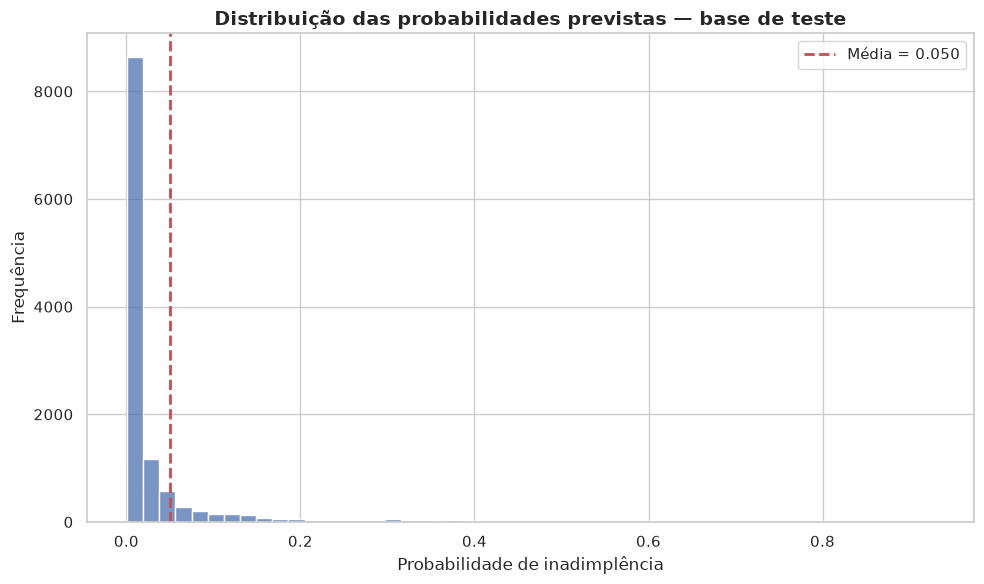

In [11]:
display(df_submissao["PROBABILIDADE_INADIMPLENCIA"].describe().to_frame())

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_submissao["PROBABILIDADE_INADIMPLENCIA"], bins=50, ax=ax, color="#4C72B0")
ax.axvline(
    df_submissao["PROBABILIDADE_INADIMPLENCIA"].mean(),
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label=f"Média = {df_submissao['PROBABILIDADE_INADIMPLENCIA'].mean():.3f}",
)
ax.set_title("Distribuição das probabilidades previstas — base de teste")
ax.set_xlabel("Probabilidade de inadimplência")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Salvando o arquivo de submissão

In [12]:
SUBMISSAO_PATH = "../submissao_case.csv"
df_submissao.to_csv(SUBMISSAO_PATH, index=False)
print(f"Arquivo salvo em: {SUBMISSAO_PATH}")

Arquivo salvo em: ../submissao_case.csv


## 4. Checagens de Sanidade

### 4.1 Primeiras linhas do arquivo de submissão

In [13]:
df_submissao.head(10)

,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIMPLENCIA
0,5058298901476893676,2021-07,0.009863
1,274692171162531764,2021-07,0.016438
2,274692171162531764,2021-07,0.019933
3,274692171162531764,2021-07,0.026013
4,465309249432033993,2021-07,0.005471
5,465309249432033993,2021-07,0.005259
6,465309249432033993,2021-07,0.006157
7,465309249432033993,2021-07,0.006157
8,5883155883105348987,2021-07,0.032127
9,5883155883105348987,2021-07,0.020733


### 4.2 Comparação com a taxa de inadimplência histórica

Comparamos a probabilidade média prevista para o teste com a taxa de inadimplência observada em toda a base de desenvolvimento (~7%). Não esperamos que sejam idênticas — a base de teste é de um período diferente e pode ter uma taxa real diferente —, mas uma discrepância muito grande seria um sinal de alerta (ex.: erro na construção de features, mudança abrupta na distribuição dos dados, ou problema no modelo).

,taxa
Taxa observada em desenvolvimento,7.02
Probabilidade média prevista (teste),4.98


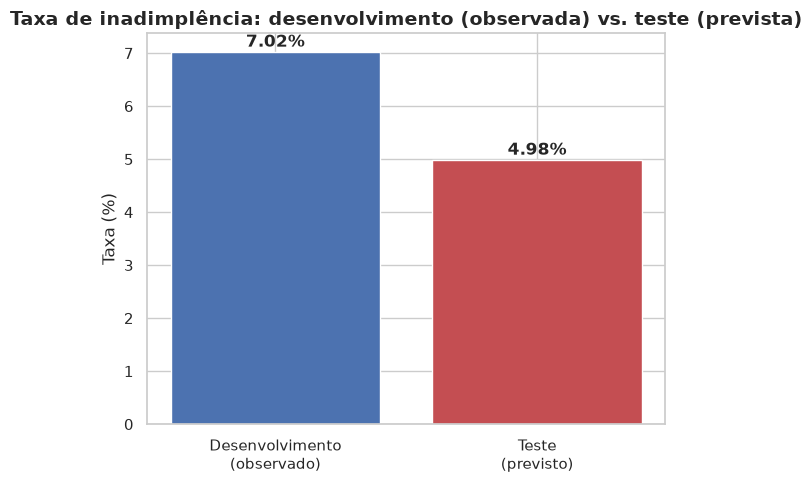

In [14]:
proba_media_teste = df_submissao["PROBABILIDADE_INADIMPLENCIA"].mean()

comparacao = pd.DataFrame(
    {
        "taxa": [TAXA_INADIMPLENCIA_DEV * 100, proba_media_teste * 100],
    },
    index=["Taxa observada em desenvolvimento", "Probabilidade média prevista (teste)"],
)
display(comparacao.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
valores = [TAXA_INADIMPLENCIA_DEV * 100, proba_media_teste * 100]
ax.bar(["Desenvolvimento\n(observado)", "Teste\n(previsto)"], valores, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(valores):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_title("Taxa de inadimplência: desenvolvimento (observada) vs. teste (prevista)")
ax.set_ylabel("Taxa (%)")
plt.tight_layout()
plt.show()

### 4.3 Alerta automático de discrepância

Sinalizamos automaticamente se a probabilidade média prevista se afastar demais da taxa histórica — usamos como limite uma razão de 1.5x para mais ou para menos (ou seja, a média prevista deveria estar, grosso modo, entre 2/3 e 1,5 vezes a taxa histórica).

In [15]:
RAZAO_LIMITE = 1.5
razao = proba_media_teste / TAXA_INADIMPLENCIA_DEV

print(f"Taxa observada em desenvolvimento: {TAXA_INADIMPLENCIA_DEV*100:.2f}%")
print(f"Probabilidade média prevista (teste): {proba_media_teste*100:.2f}%")
print(f"Razão (previsto / observado): {razao:.2f}x")

if (1 / RAZAO_LIMITE) <= razao <= RAZAO_LIMITE:
    print(f"\nOK: a probabilidade média prevista está dentro de uma faixa razoável em relação à taxa histórica (limite: {RAZAO_LIMITE}x).")
else:
    print(
        f"\nATENÇÃO: a probabilidade média prevista está muito distante da taxa histórica "
        f"(razão de {razao:.2f}x, fora da faixa [{1/RAZAO_LIMITE:.2f}x, {RAZAO_LIMITE:.2f}x]). "
        "Investigar possível problema na geração de features, mudança de distribuição entre "
        "desenvolvimento e teste, ou erro no pipeline antes de considerar a submissão válida."
    )

Taxa observada em desenvolvimento: 7.02%
Probabilidade média prevista (teste): 4.98%
Razão (previsto / observado): 0.71x

OK: a probabilidade média prevista está dentro de uma faixa razoável em relação à taxa histórica (limite: 1.5x).


---

O arquivo `submissao_case.csv` foi gerado na raiz do projeto, com uma linha por cobrança da base de teste e a probabilidade de inadimplência prevista pelo modelo final (LightGBM, hiperparâmetros otimizados via Optuna e validados com split temporal no notebook `03_modelagem.ipynb`).